# Notebook 02 — Exploratory Data Analysis (EDA)

**Proyek:** Segmentasi Pelanggan untuk Mengatasi Ketidakefektifan Strategi Pemasaran Menggunakan Metode RFM dan Algoritma K-Means

## Tujuan EDA
EDA bertujuan memahami **bentuk distribusi**, **pola temporal**, **hubungan antar variabel**, serta **anomali** pada dataset Olist sebelum tahap preprocessing dan modeling.

Cakupan analisis:
1. **Univariate** – distribusi tiap variabel kunci.
2. **Bivariate**  – hubungan antar dua variabel.
3. **Multivariate** – korelasi & interaksi banyak variabel.
4. **Time-series** – pola transaksi sepanjang waktu.
5. **Outlier**     – nilai ekstrem yang berpotensi mengganggu clustering.
6. **Geografis**   – distribusi pelanggan per state.

## 1. Setup

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

PROJECT_ROOT = Path('..').resolve()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    """Helper menyimpan figure ke reports/figures/."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'{name}.png', dpi=120, bbox_inches='tight')
    plt.show()

print('Setup selesai.')

Matplotlib is building the font cache; this may take a moment.


Setup selesai.


## 2. Memuat Tabel-tabel Utama

In [2]:
orders     = pd.read_csv(RAW_DIR / 'olist_orders_dataset.csv',
                         parse_dates=['order_purchase_timestamp', 'order_approved_at',
                                      'order_delivered_carrier_date',
                                      'order_delivered_customer_date',
                                      'order_estimated_delivery_date'])
customers  = pd.read_csv(RAW_DIR / 'olist_customers_dataset.csv')
items      = pd.read_csv(RAW_DIR / 'olist_order_items_dataset.csv',
                         parse_dates=['shipping_limit_date'])
payments   = pd.read_csv(RAW_DIR / 'olist_order_payments_dataset.csv')
reviews    = pd.read_csv(RAW_DIR / 'olist_order_reviews_dataset.csv',
                         parse_dates=['review_creation_date', 'review_answer_timestamp'])
products   = pd.read_csv(RAW_DIR / 'olist_products_dataset.csv')
cat_trans  = pd.read_csv(RAW_DIR / 'product_category_name_translation.csv')

print('orders   :', orders.shape)
print('customers:', customers.shape)
print('items    :', items.shape)
print('payments :', payments.shape)
print('reviews  :', reviews.shape)
print('products :', products.shape)

orders   : (99441, 8)
customers: (99441, 5)
items    : (112650, 7)
payments : (103886, 5)
reviews  : (99224, 7)
products : (32951, 9)


## 3. Univariate Analysis

### 3.1 Status Order
Status order menentukan order mana yang valid untuk dimasukkan dalam analisis RFM (hanya `delivered` yang merupakan transaksi yang benar-benar terjadi).

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


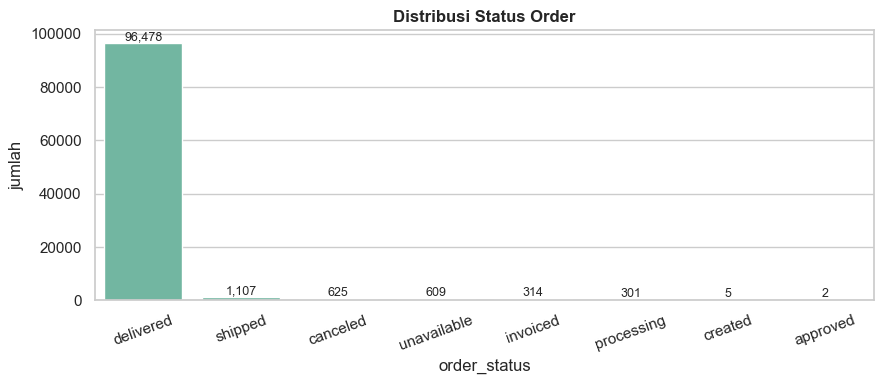

In [3]:
status_counts = orders['order_status'].value_counts()
print(status_counts)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=status_counts.index, y=status_counts.values, ax=ax)
ax.set_title('Distribusi Status Order')
ax.set_xlabel('order_status'); ax.set_ylabel('jumlah')
for i, v in enumerate(status_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=20)
savefig('univariate_order_status')

### 3.2 Distribusi Nilai Pembayaran (Monetary)

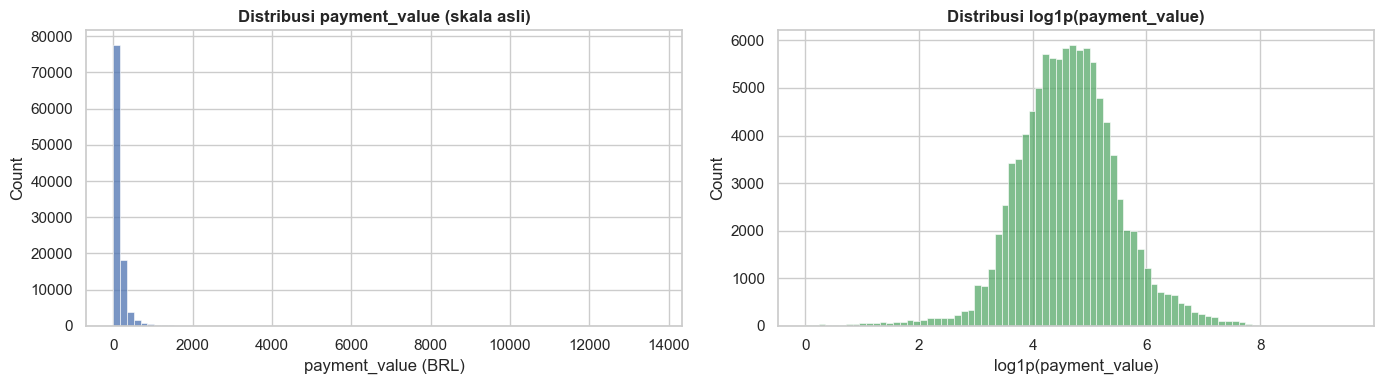

count    103886.00
mean        154.10
std         217.49
min           0.00
25%          56.79
50%         100.00
75%         171.84
max       13664.08
Name: payment_value, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(payments['payment_value'], bins=80, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribusi payment_value (skala asli)')
axes[0].set_xlabel('payment_value (BRL)')

sns.histplot(np.log1p(payments['payment_value']), bins=80, ax=axes[1], color='#55A868')
axes[1].set_title('Distribusi log1p(payment_value)')
axes[1].set_xlabel('log1p(payment_value)')
savefig('univariate_payment_value')

print(payments['payment_value'].describe().round(2))

### 3.3 Tipe Pembayaran

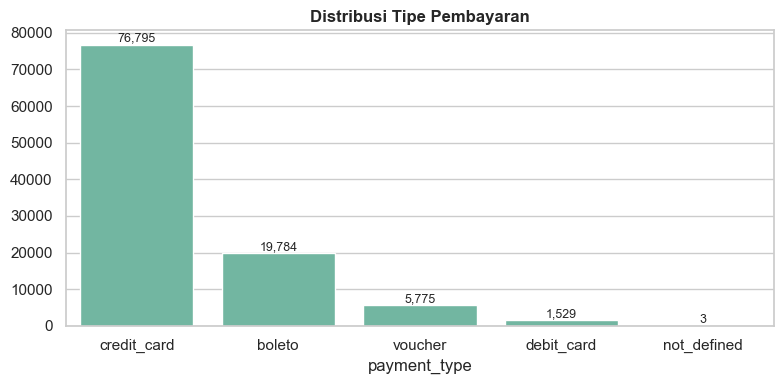

In [5]:
ptype = payments['payment_type'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=ptype.index, y=ptype.values, ax=ax)
ax.set_title('Distribusi Tipe Pembayaran')
for i, v in enumerate(ptype.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
savefig('univariate_payment_type')

### 3.4 Distribusi Skor Review

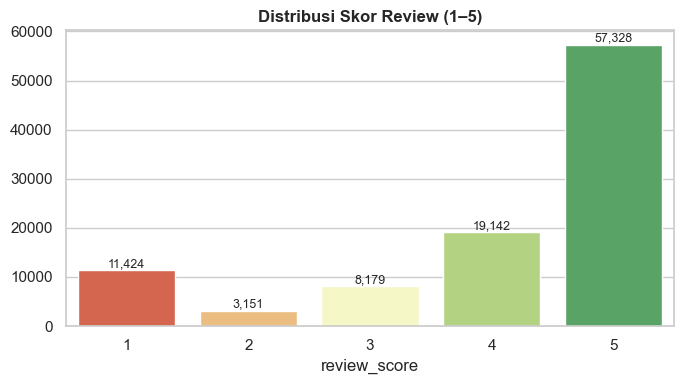

Mean review score : 4.09


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
rev_counts = reviews['review_score'].value_counts().sort_index()
sns.barplot(x=rev_counts.index, y=rev_counts.values, palette='RdYlGn', ax=ax)
ax.set_title('Distribusi Skor Review (1–5)')
for i, v in enumerate(rev_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
savefig('univariate_review_score')
print('Mean review score :', round(reviews['review_score'].mean(), 2))

### 3.5 Distribusi Cicilan (Installments)

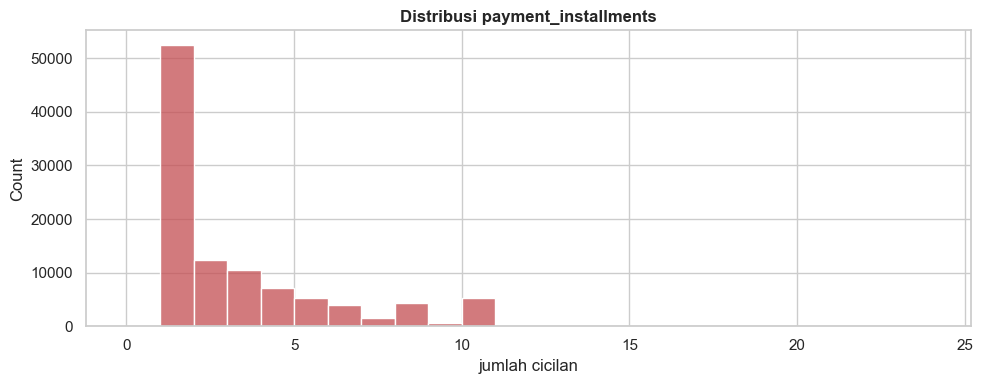

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(payments['payment_installments'], bins=24, ax=ax, color='#C44E52')
ax.set_title('Distribusi payment_installments')
ax.set_xlabel('jumlah cicilan')
savefig('univariate_installments')

## 4. Bivariate Analysis

### 4.1 Tipe Pembayaran vs Nilai Pembayaran

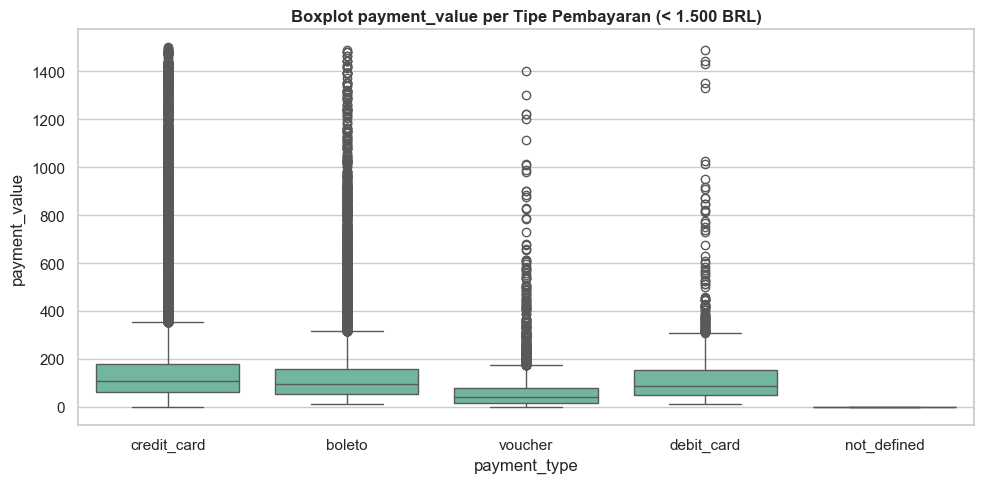

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=payments[payments['payment_value'] < 1500],
            x='payment_type', y='payment_value', ax=ax)
ax.set_title('Boxplot payment_value per Tipe Pembayaran (< 1.500 BRL)')
savefig('bivariate_paytype_value')

### 4.2 Skor Review vs Lead Time Pengiriman

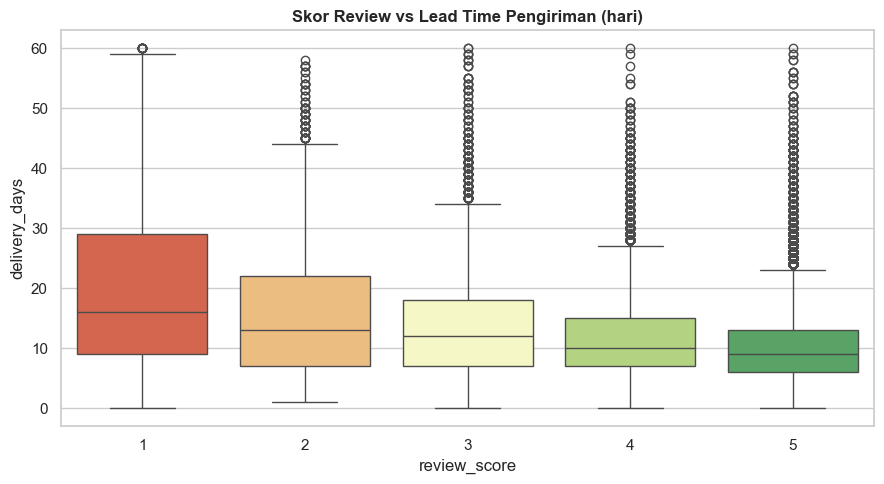

In [9]:
delivered = orders.dropna(subset=['order_delivered_customer_date']).copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date']
                              - delivered['order_purchase_timestamp']).dt.days
merged_dr = delivered.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=merged_dr[merged_dr['delivery_days'].between(0, 60)],
            x='review_score', y='delivery_days', palette='RdYlGn', ax=ax)
ax.set_title('Skor Review vs Lead Time Pengiriman (hari)')
savefig('bivariate_review_delivery')

### 4.3 Top-15 Kategori Produk berdasarkan Total Pendapatan

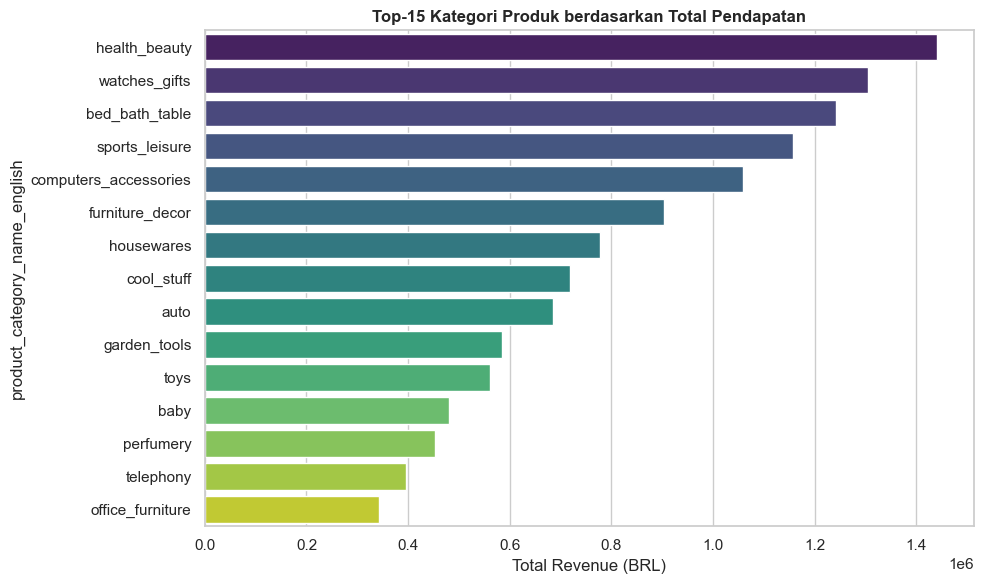

In [10]:
items_prod = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_prod = items_prod.merge(cat_trans, on='product_category_name', how='left')
rev_per_cat = (items_prod.assign(revenue=lambda d: d['price'] + d['freight_value'])
               .groupby('product_category_name_english')['revenue'].sum()
               .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=rev_per_cat.values, y=rev_per_cat.index, ax=ax, palette='viridis')
ax.set_title('Top-15 Kategori Produk berdasarkan Total Pendapatan')
ax.set_xlabel('Total Revenue (BRL)')
savefig('bivariate_top_categories')

## 5. Multivariate Analysis

### 5.1 Korelasi Variabel Numerik di Tabel `payments` & `items`

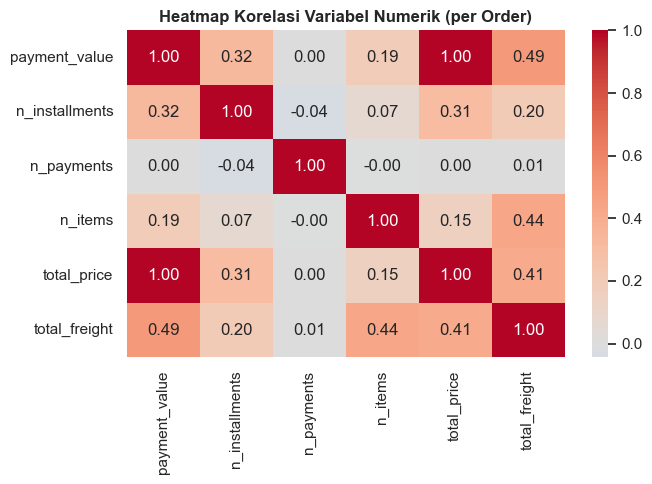

In [11]:
# gabungkan payment & item per order untuk lihat korelasi numerik
agg_pay = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    n_installments=('payment_installments', 'max'),
    n_payments=('payment_sequential', 'count'),
).reset_index()
agg_item = items.groupby('order_id').agg(
    n_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
).reset_index()
merged_oi = agg_pay.merge(agg_item, on='order_id', how='inner')

corr = merged_oi.drop(columns='order_id').corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Heatmap Korelasi Variabel Numerik (per Order)')
savefig('multivariate_corr_heatmap')

### 5.2 Pairplot pada Sampel

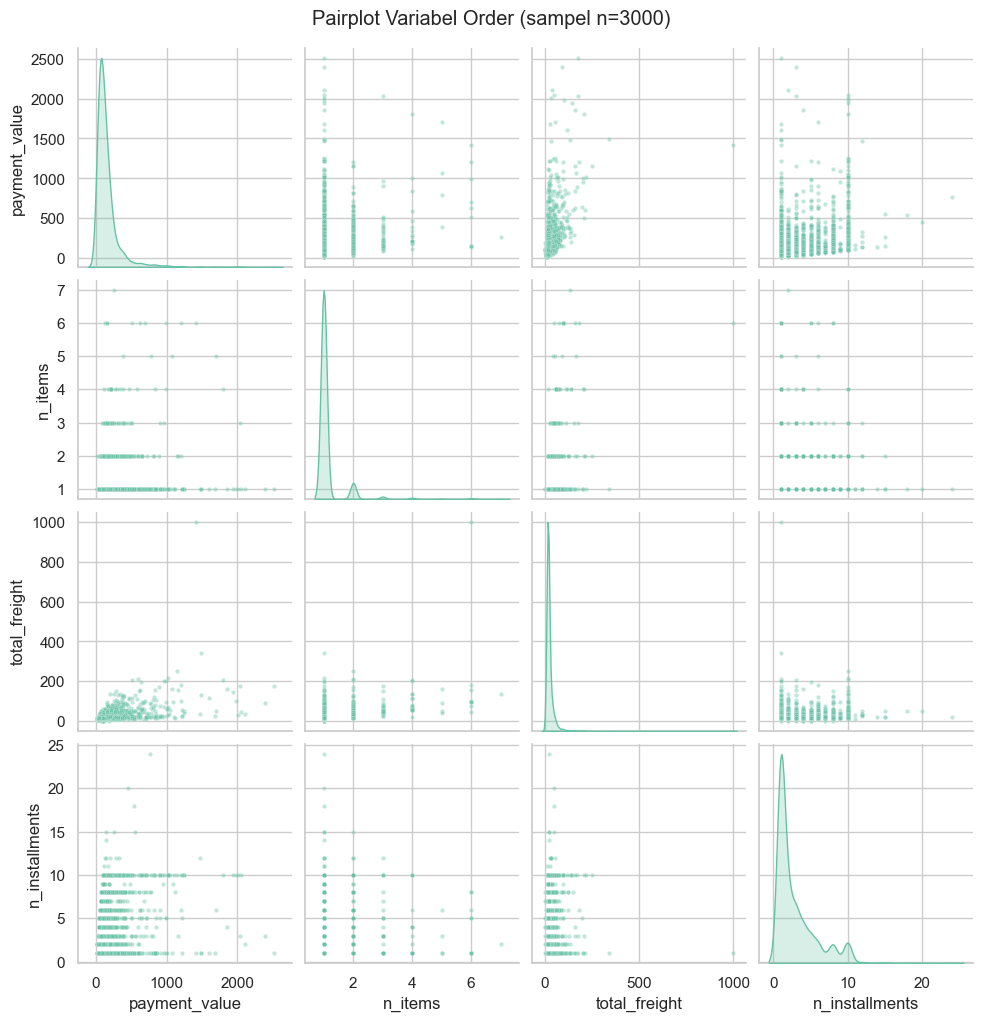

In [12]:
sample = merged_oi.sample(3000, random_state=42)
g = sns.pairplot(sample[['payment_value', 'n_items', 'total_freight', 'n_installments']],
                  diag_kind='kde', plot_kws={'alpha': 0.4, 's': 10})
g.fig.suptitle('Pairplot Variabel Order (sampel n=3000)', y=1.02)
plt.savefig(FIG_DIR / 'multivariate_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Time-Series Analysis

### 6.1 Jumlah Order per Bulan

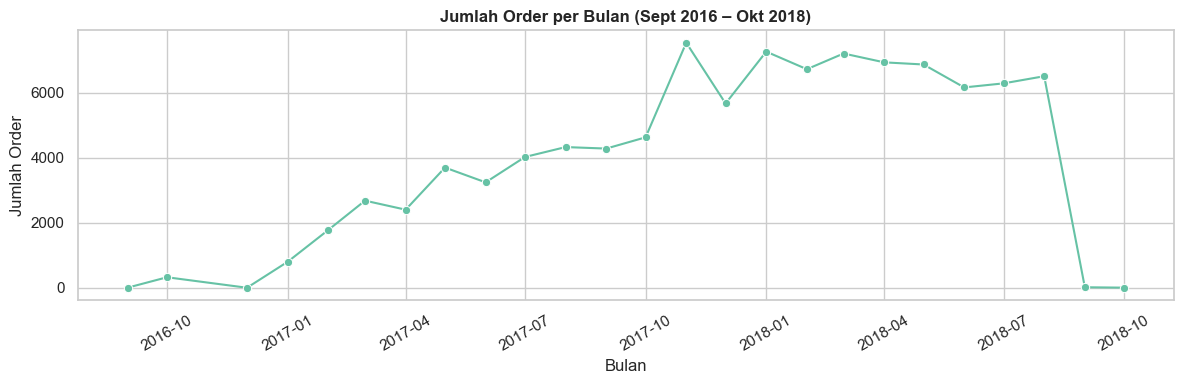

In [13]:
orders_ts = orders.copy()
orders_ts['ym'] = orders_ts['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
monthly = orders_ts.groupby('ym').size().rename('n_orders').reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=monthly, x='ym', y='n_orders', marker='o', ax=ax)
ax.set_title('Jumlah Order per Bulan (Sept 2016 – Okt 2018)')
ax.set_xlabel('Bulan'); ax.set_ylabel('Jumlah Order')
plt.xticks(rotation=30)
savefig('timeseries_orders_per_month')

### 6.2 Pola Order per Hari Dalam Seminggu & Per Jam

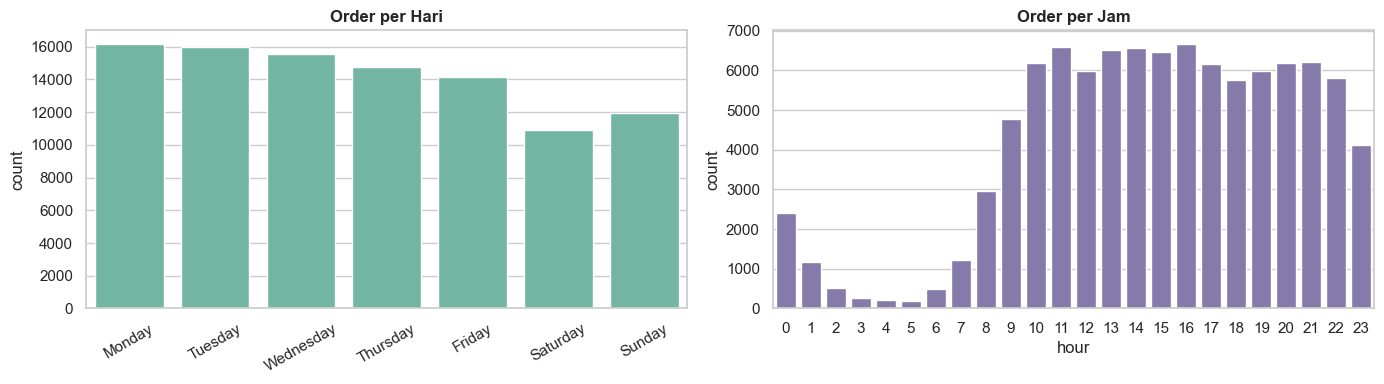

In [14]:
orders_ts['dow'] = orders_ts['order_purchase_timestamp'].dt.day_name()
orders_ts['hour'] = orders_ts['order_purchase_timestamp'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order_dow = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.countplot(data=orders_ts, x='dow', order=order_dow, ax=axes[0])
axes[0].set_title('Order per Hari'); axes[0].set_xlabel('')
for lbl in axes[0].get_xticklabels(): lbl.set_rotation(30)

sns.countplot(data=orders_ts, x='hour', ax=axes[1], color='#8172B2')
axes[1].set_title('Order per Jam')
savefig('timeseries_dow_hour')

## 7. Outlier Detection

Boxplot pada variabel kunci yang akan menjadi input RFM.

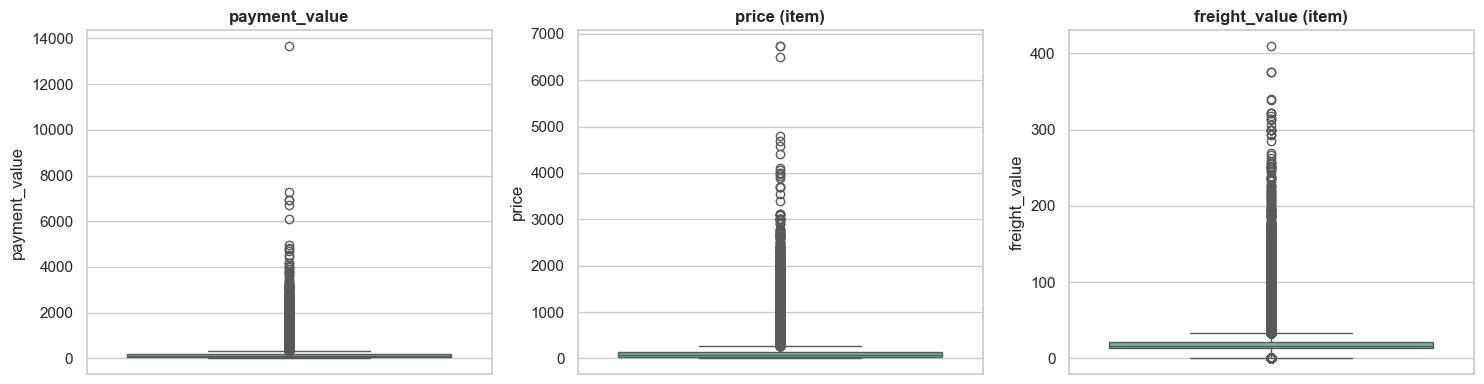

Outlier (IQR) payment_value : 7.68%
Outlier (IQR) item price    : 7.48%
Outlier (IQR) freight_value : 10.77%


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=payments['payment_value'], ax=axes[0])
axes[0].set_title('payment_value')
sns.boxplot(y=items['price'], ax=axes[1])
axes[1].set_title('price (item)')
sns.boxplot(y=items['freight_value'], ax=axes[2])
axes[2].set_title('freight_value (item)')
savefig('outlier_boxplots')

def iqr_outlier(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < lo) | (s > hi)).mean() * 100

print(f'Outlier (IQR) payment_value : {iqr_outlier(payments["payment_value"]):.2f}%')
print(f'Outlier (IQR) item price    : {iqr_outlier(items["price"]):.2f}%')
print(f'Outlier (IQR) freight_value : {iqr_outlier(items["freight_value"]):.2f}%')

## 8. Distribusi Geografis Pelanggan

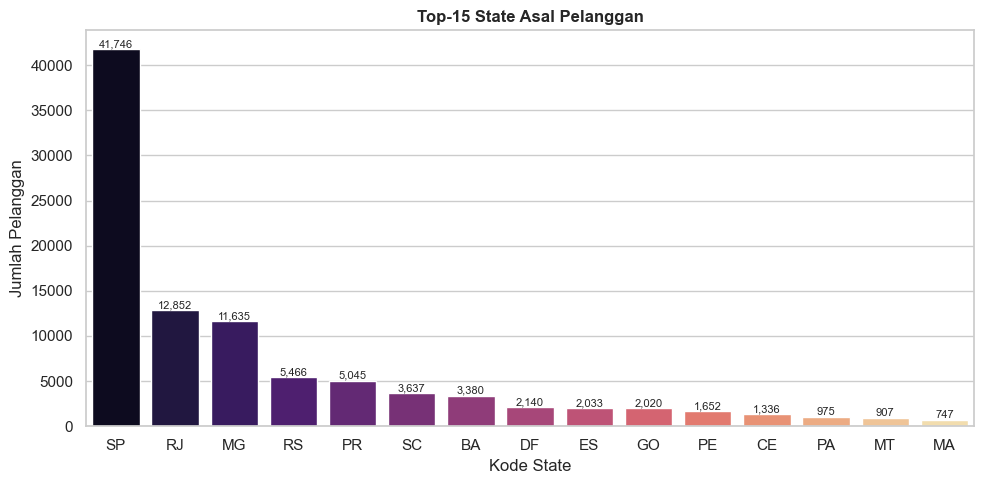

Total state unik : 27


In [16]:
state_count = customers['customer_state'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=state_count.index, y=state_count.values, ax=ax, palette='magma')
ax.set_title('Top-15 State Asal Pelanggan')
ax.set_xlabel('Kode State'); ax.set_ylabel('Jumlah Pelanggan')
for i, v in enumerate(state_count.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
savefig('geo_top_states')
print('Total state unik :', customers['customer_state'].nunique())

## 9. Frekuensi Pembelian per Pelanggan (Repeat Buyers)

Melihat seberapa banyak pelanggan yang melakukan order berulang. Ini relevan untuk komponen **Frequency** dalam RFM.

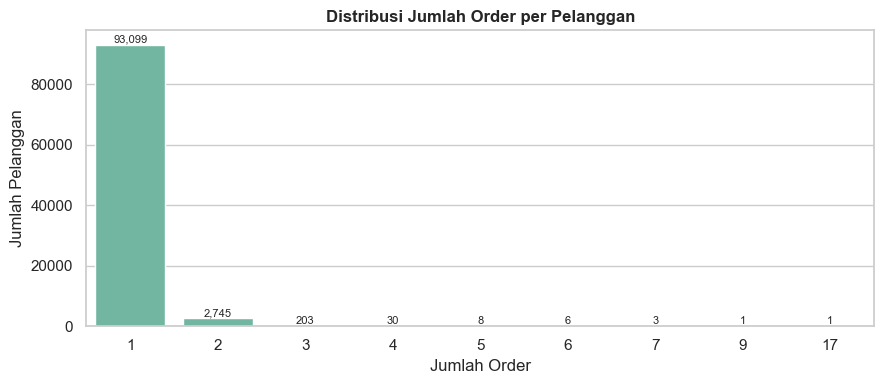

Total pelanggan unik         : 96096
Pelanggan dengan >=2 order   : 2997 (3.12%)


In [17]:
od_cust = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
freq_per_cust = od_cust.groupby('customer_unique_id')['order_id'].nunique()

freq_dist = freq_per_cust.value_counts().sort_index().head(10)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=freq_dist.index, y=freq_dist.values, ax=ax)
ax.set_title('Distribusi Jumlah Order per Pelanggan')
ax.set_xlabel('Jumlah Order'); ax.set_ylabel('Jumlah Pelanggan')
for i, v in enumerate(freq_dist.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
savefig('frequency_per_customer')

print('Total pelanggan unik         :', freq_per_cust.size)
print('Pelanggan dengan >=2 order   :', (freq_per_cust >= 2).sum(),
      f'({(freq_per_cust >= 2).mean()*100:.2f}%)')

## 10. Insight Utama EDA

1. **Status order** sangat dominan `delivered` (~ 97%). Untuk RFM hanya order ini yang akan dipakai.
2. **payment_value** sangat *right-skewed* (banyak nilai kecil + sedikit nilai sangat besar).    Akan perlu **transformasi log** atau **scaling robust** sebelum K-Means.
3. **Tipe pembayaran** didominasi `credit_card` (~ 74%) lalu `boleto` (~ 19%).
4. **Skor review** condong ke skor 5 (mean ~ 4,1). Ada hubungan kuat: **lead time pengiriman lebih lama → skor review lebih rendah**.
5. Korelasi terkuat: `payment_value ↔ total_price` (~ 0,98) dan `n_items ↔ total_price`.
6. **Pola temporal**: order naik tajam dari awal 2017, puncak November 2017 (Black Friday), turun di akhir periode (data terpotong).
7. **Outlier**: ~ 6–9% pada `payment_value`, perlu treatment di tahap preprocessing.
8. Pelanggan **mayoritas hanya membeli 1 kali** (~ 97%) — Frequency akan minim sebaran, tetap relevan untuk segmentasi karena masih menyumbang sinyal.

Tahap berikutnya: **Notebook 03 – Data Preprocessing**.